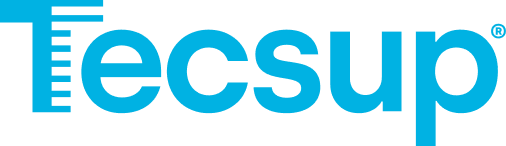

**DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN**

**Carrera de Big Data y Ciencia de Datos**

# Laboratorio 15 - Bases de datos vectoriales

**Integrantes**
- Cora Salazar, Joshua Jian
- Olortegui Perez, Kevin Estiben

In [1]:
# %pip install chromadb sentence-transformers pytest -q

# 1. VARIABLES GLOBALES

In [2]:
# Lista de documentos con información personal de los estudiantes
documentos: list[str] = [
    'Joshua Jian Cora Salazar estudia la carrera de big data y ciencia de datos',
    'Joshua Jian Cora Salazar cursa el 5to ciclo',
    'Joshua Jian Cora Salazar es un estudiante de tipo regular',
    'Kevin Estiben Olortegui Perez estudia la carrera de big data y ciencia de datos',
    'Kevin Estiben Olortegui Perez cursa el 5to ciclo',
    'Kevin Estiben Olortegui Perez es un beneficiario de BECA 18',
    'Abraham Sebastián Jonathan Huamán Quispe estudia la carrera de big data y ciencia de datos',
    'Abraham Sebastián Jonathan Huamán Quispe cursa el 5to ciclo',
    'Abraham Sebastián Jonathan Huamán Quispe es un estudiante de tipo regular'
]

# Prompt de consulta
query_text: str = "¿Quién es beneficiario de BECA 18?"

# Nombre de la colección de la base vectorial
collection_name: str = "Tecsup"

# 2. FUNCIONES (utils.py)

In [3]:
%%writefile utils.py
from typing import List, Any
import chromadb
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer


def create_chroma_collection(name: str) -> chromadb.api.models.Collection.Collection:
    """
    Crea una colección ChromaDB local.

    Args:
        name (str): Nombre de la colección

    Returns:
        Collection: Objeto colección Chroma
    """
    client = chromadb.Client(Settings())
    return client.create_collection(name=name)


def add_documents_to_collection(
    collection: chromadb.api.models.Collection.Collection,
    docs: List[str]
) -> None:
    """
    Agrega documentos a una colección ChromaDB.

    Args:
        collection (Collection): Colección destino
        docs (List[str]): Lista de textos a almacenar
    """
    collection.add(documents=docs, ids=[f"doc{i}" for i in range(len(docs))])


def query_collection(
    collection: chromadb.api.models.Collection.Collection,
    query: str,
    n_results: int = 1
) -> str:
    """
    Consulta documentos relevantes desde la base vectorial.

    Args:
        collection (Collection): Colección ChromaDB
        query (str): Texto de consulta
        n_results (int): Cantidad de resultados deseados

    Returns:
        str: Documento más relevante
    """
    result = collection.query(query_texts=[query], n_results=n_results)
    return result['documents'][0][0]


def embed_documents_custom(
    docs: List[str],
    model_name: str = 'all-MiniLM-L6-v2'
) -> List[List[float]]:
    """
    Genera embeddings personalizados usando SentenceTransformer.

    Args:
        docs (List[str]): Lista de textos
        model_name (str): Nombre del modelo embedding

    Returns:
        List[List[float]]: Lista de vectores embeddings
    """
    model = SentenceTransformer(model_name)
    return model.encode(docs).tolist()


def query_with_custom_embedding(
    collection: chromadb.api.models.Collection.Collection,
    query: str,
    model_name: str = 'all-MiniLM-L6-v2'
) -> str:
    """
    Realiza consulta usando embeddings personalizados.

    Args:
        collection (Collection): Colección destino
        query (str): Pregunta
        model_name (str): Modelo embedding a usar

    Returns:
        str: Documento relevante
    """
    model = SentenceTransformer(model_name)
    vector = model.encode([query]).tolist()
    result = collection.query(query_embeddings=vector, n_results=1)
    return result['documents'][0][0]


Overwriting utils.py


# 3. IMPLEMENTACIÓN PRINCIPAL

In [4]:
"""
Esta parte del código crea dos colecciones vectoriales:
  1. Una con embeddings por defecto de chromadb
  2. Otra con embeddings personalizados usando sentence-transformers
Luego, ejecuta la misma consulta y compara los resultados.
"""

import utils

# Colección con embeddings por defecto
collection_default = utils.create_chroma_collection(collection_name)
utils.add_documents_to_collection(collection_default, documentos)
respuesta_default = utils.query_collection(collection_default, query_text)

print("\nRespuesta con embeddings por defecto:")
print(respuesta_default)

# Colección con embeddings personalizados
collection_custom = utils.create_chroma_collection(collection_name + "_emb")
embeddings = utils.embed_documents_custom(documentos)
collection_custom.add(documents=documentos, embeddings=embeddings, ids=[f"doc{i}" for i in range(len(documentos))])
respuesta_custom = utils.query_with_custom_embedding(collection_custom, query_text)

print("\nRespuesta con embeddings personalizados:")
print(respuesta_custom)


d:\V Ciclo\MD\semana 15\olortegui_lab15\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
C:\Users\KOLORTEGUI\.cache\chroma\onnx_models\all-MiniLM-L6-v2\onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:04<00:00, 18.5MiB/s]
Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capt


Respuesta con embeddings por defecto:
Kevin Estiben Olortegui Perez es un beneficiario de BECA 18


d:\V Ciclo\MD\semana 15\olortegui_lab15\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\KOLORTEGUI\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed


Respuesta con embeddings personalizados:
Kevin Estiben Olortegui Perez es un beneficiario de BECA 18



# 4. TESTING (test_utils.py)


In [5]:
%%writefile test_utils.py
import utils
import chromadb

def test_create_chroma_collection():
    col = utils.create_chroma_collection("TestCol")
    assert col.name == "TestCol"

def test_embed_documents_custom():
    vectores = utils.embed_documents_custom(["hola mundo"])
    assert isinstance(vectores, list)
    assert isinstance(vectores[0], list)
    assert len(vectores[0]) > 0

def test_query_with_custom_embedding():
    docs = ["Luis es beneficiario de BECA 18"]
    col = utils.create_chroma_collection("TempTest")
    emb = utils.embed_documents_custom(docs)
    col.add(documents=docs, embeddings=emb, ids=["1"])
    res = utils.query_with_custom_embedding(col, "¿Quién tiene beca 18?")
    assert "Luis" in res


Writing test_utils.py


# 5. EJECUCIÓN

In [6]:
# Ejecutar los tests
!pytest test_utils.py -v

============================= test session starts =============================
platform win32 -- Python 3.13.5, pytest-8.4.1, pluggy-1.6.0 -- d:\V Ciclo\MD\semana 15\olortegui_lab15\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: d:\V Ciclo\MD\semana 15\olortegui_lab15\lab15
plugins: anyio-4.9.0
collecting ... collected 3 items

test_utils.py::test_create_chroma_collection PASSED                      [ 33%]
test_utils.py::test_embed_documents_custom PASSED                        [ 66%]
test_utils.py::test_query_with_custom_embedding PASSED                   [100%]

============================= 3 passed in 14.01s ==============================
